# 게임 세계관 분석 실험

**파이프라인 흐름:**
1. 게임 텍스트 JSON 로드
2. 영어 텍스트 → Word Cloud 생성 (불용어 제거)
3. GPT로 세계관/어투 분석

**필요한 패키지:**
```bash
pip install wordcloud matplotlib openai pandas
```


In [1]:
# 패키지 설치 (첫 실행 시)
# !pip install wordcloud matplotlib openai pandas

In [1]:
import os
from pathlib import Path
import destiny2_analysis as d2

try:
    from dotenv import load_dotenv
    for _env in [Path.cwd() / '.env', Path.cwd().parent / '.env']:
        load_dotenv(_env, override=False)
except Exception:
    pass

# ⚠️ OpenAI API 키를 여기에 입력하세요
API_KEY = os.getenv('OPENAI_API_KEY')
if not API_KEY:
    raise ValueError('OPENAI_API_KEY? .env? ??????.')

# 분석할 JSON 파일 경로
DATA_PATH = "destiny2_translation.json"

## Step 1. 데이터 로드

In [2]:
data = d2.load_data(DATA_PATH)

# 데이터 구조 확인
from collections import Counter
import pandas as pd

type_counts = Counter(d["type"] for d in data)
domain_counts = Counter(d["domain"] for d in data)

print("타입별 개수:", dict(type_counts))
print("도메인별 개수:", dict(domain_counts))

# 샘플 5개 보기
pd.DataFrame(data[:5])[["id", "type", "domain", "en", "ko"]]

총 40609개 항목 로드 완료
타입별 개수: {'name': 23367, 'description': 13206, 'lore_description': 2483, 'lore_subtitle': 1499, 'lore_name': 54}
도메인별 개수: {'item': 22913, 'activity': 2967, 'perk': 3006, 'quest': 370, 'system': 7317, 'lore': 4036}


,id,type,domain,en,ko
0,0,name,item,Legendary Engram,전설 엔그램
1,1,description,item,An engram with complex markers. Contains a ran...,복잡한 표시가 있는 엔그램입니다. 무작위 전설 무기 또는 방어구가 들어 있습니다.
2,2,name,item,Spacewalk Cloak,우주 유영 망토
3,3,name,item,Tangled Web Helm,뒤엉킨 거미줄 투구
4,4,name,item,Raven Shard,까마귀 파편


## Step 2. Word Cloud 생성

- `description`, `lore_subtitle` 텍스트 사용
- 일반 영어 불용어 + 게임 UI 잡음어 제거 → 세계관 핵심 단어가 부각됩니다


In [3]:
# 텍스트 추출
wc_texts = d2.get_texts_by_type(
    data,
    types={"description", "lore_subtitle"},
)
print(f"대상 텍스트: {len(wc_texts)}개")

# 단어 추출 & 빈도 계산
words = d2.clean_text(wc_texts)
top_words = d2.get_top_words(words, n=30)

print("\n상위 30개 단어:")
for word, count in top_words:
    print(f"  {word:20s} {count}")

대상 텍스트: 14705개

상위 30개 단어:
  weapon               1762
  complete             1721
  defeat               1505
  damage               1468
  ornament             1159
  combatants           1126
  final                892
  targets              808
  blows                745
  armor                680
  appearance           646
  weapons              619
  change               576
  energy               568
  void                 562
  contains             529
  time                 519
  speed                514
  arc                  505
  solar                495
  difficulty           463
  defeating            460
  season               450
  fireteam             420
  full                 414
  ability              414
  guardians            412
  additional           407
  stasis               407
  lost                 402


c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 44172 (\N{HANGUL SYLLABLE GE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destiny2_analysis.py:116: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\destin

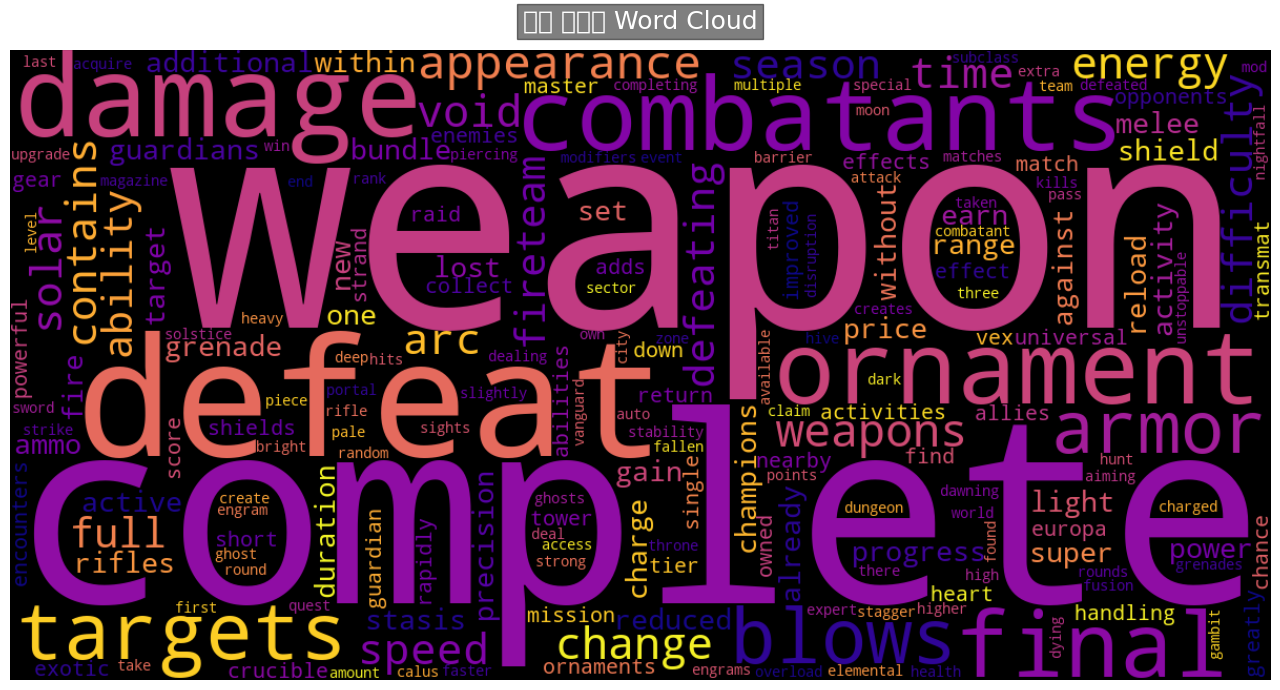

Word Cloud 저장: wordcloud_game.png


'wordcloud_game.png'

In [4]:
# Word Cloud 생성 및 저장
d2.make_wordcloud(words)

## Step 3. GPT로 세계관 / 어투 분석

- 상위 100개 단어 + 텍스트 샘플을 GPT에 전달
- 시대 배경, 어조, 핵심 테마를 도출합니다


In [5]:
# description 텍스트 샘플 확인 (lore_description 제외)
desc_only_texts = d2.get_texts_by_type(data, types={"description"})
desc_samples = sorted(desc_only_texts, key=len, reverse=True)[:3]

print(f"description 텍스트 수 {len(desc_only_texts)}개")
print("\n--- 가장 긴 description 샘플 미리보기 ---")
print(desc_samples[0][:500], "...")


description 텍스트 수 13206개

--- 가장 긴 description 샘플 미리보기 ---
• Earn Medallions from completing Contender or Platinum Cards (acquired from Eva) or ritual activities with your class item equipped. Medallions can be banked at the podium in the Tower for event rewards, and they will contribute toward your class standing! • Acquire Diamond Contender Cards from Eva in order to earn incredibly lucrative Diamond Medallions! • Achieving high scores in the "Vying for Supremacy" or "Shoot to Score" quests will allow you to light torches and unlock Tower chests. Towe ...


In [6]:
# GPT 세계관 분석 실행
top_words_100 = d2.get_top_words(words, n=100)
analysis = d2.analyze_worldview_with_gpt(top_words_100, desc_samples, API_KEY)

from IPython.display import Markdown
Markdown(analysis)

1. **시대 배경 및 세계관**  
   이 게임은 SF 판타지 세계관을 배경으로 하고 있습니다. "Guardians", "Traveler", "void", "energy"와 같은 용어는 초자연적인 힘과 기술이 결합된 환경을 암시합니다. "Lost Sector"와 "Cyst" 같은 표현은 탐험과 전투가 중요한 요소로 작용하는 세계를 나타내며, 플레이어가 다양한 전투 활동을 통해 보상을 얻는 구조를 가지고 있습니다. 이러한 요소들은 고대의 신화적 존재와 현대적 기술이 결합된 복합적인 세계를 형성하고 있습니다.

2. **서술 어조 및 분위기**  
   내러티브의 톤은 서사적이며, 경쟁과 협동의 요소가 강조됩니다. "defeat", "combatants", "final blow"와 같은 단어들이 사용되어 전투의 긴장감과 목표 지향적인 분위기를 조성합니다. 또한, "blessings", "rewards", "earn" 등 긍정적인 요소가 포함되어 있어 플레이어에게 성취감을 주는 서술 방식이 돋보입니다. 전반적으로 도전과 성공의 경험을 중시하는 분위기를 갖추고 있습니다.

3. **핵심 테마**  
   반복적으로 등장하는 주제는 경쟁, 전투, 그리고 보상입니다. "defeating", "points", "streak", "energy"와 같은 단어들은 플레이어 간의 경쟁과 그에 따른 성과를 강조합니다. 또한, "Traveler's Blessings"와 같은 보상 시스템은 플레이어가 지속적으로 활동하고 성장할 수 있는 동기를 제공합니다. 이러한 요소들은 전투와 성취의 순환 구조를 형성하고 있습니다.

4. **문체 특징**  
   문장 구조는 간결하고 명확하며, 주로 명령형과 설명형 문장이 사용됩니다. 예를 들어, "Earn Medallions", "Acquire Diamond Contender Cards"와 같은 표현은 직접적이고 행동을 유도하는 방식으로 구성되어 있습니다. 또한, 전문 용어와 게임 내 고유 명사가 자주 등장하여 게임의 세계관을 효과적으로 전달합니다. 이러한 문체는 플레이어가 쉽게 이해하고 몰입할 수 있도록 돕습니다.

5. **한국어 번역 가이드라인**  
   - **경어 사용 여부**: 게임의 특성상 주로 반말을 사용하되, 공식적인 설명이나 안내 문구에서는 존댓말을 사용할 수 있습니다. 예를 들어, "메달리온을 얻으세요" 대신 "메달리온을 얻으십시오"와 같이 조절합니다.
   - **어휘 선택 방향**: 게임의 전문성과 몰입감을 유지하기 위해 한자어와 순우리말을 적절히 혼합합니다. 예를 들어, "전투"와 "보상" 같은 용어는 한자어를 사용하고, "빛"이나 "어둠" 같은 기본적인 개념은 순우리말을 사용합니다. 영어 직역은 피하고 자연스러운 한국어 표현을 우선합니다.
   - **어조 유지를 위한 팁**: 서사적이고 긴장감 있는 어조를 유지하기 위해, 강한 동사와 명확한 표현을 사용합니다. 예를 들어, "적을 처치하라"와 같은 명령형 표현을 활용하여 긴장감을 조성하고, 보상과 성취를 강조하는 문구를 적절히 배치하여 플레이어의 동기를 부여합니다.

In [7]:
# 분석 결과 저장 (텍스트 + JSON)
from pathlib import Path
import json

# 1) 텍스트 파일 저장 (WORLDVIEW_CONTEXT로 바로 쓰기 좋음)
txt_path = Path("worldview_context.txt")
txt_path.write_text(analysis, encoding="utf-8")

# 2) JSON 저장 (기존 호환)
json_path = Path("game_analysis_results.json")
payload = {
    "worldview_analysis": analysis,
    "translation_samples": []
}
json_path.write_text(json.dumps(payload, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved txt :", txt_path.resolve())
print("saved json:", json_path.resolve())

saved txt : C:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\worldview_context.txt
saved json: C:\Users\LLOYDK\Desktop\Demo\LLM_Translation-pseudo_lab\game_analysis_results.json
